### Library import

In [2]:
import numpy as np  # math library
import pandas as pd  # Library to handle databases
import matplotlib.pyplot as plt  # Graphic library
from scipy import stats  # stat library
import seaborn as sns  # Graphic library specialized in stats
import statsmodels.api as sm  # statistic modelling library

# Maximum likelihood estimation

## Bernoulli random variables

### Question 1
Generate a sample of size $N=5$ from a Bernoulli distribution with support $\{0,1\}$ and probability $p=0.3$.

Make a graphical representation of the empirical PMF and the theoretical PMF using a stem plot.

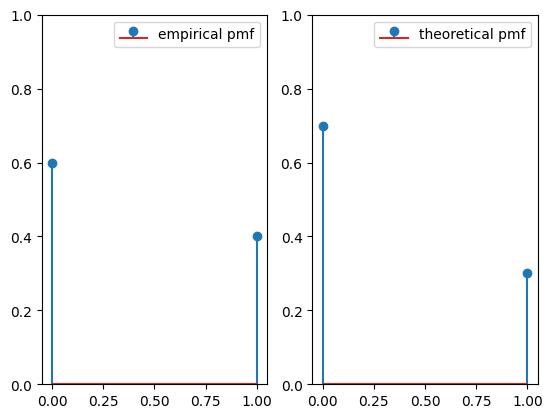

In [8]:
N = 5   # Number of samples
p = 0.3
X = np.random.binomial(1, p, N)  # Generate the sample

p_hat = np.mean(X)  # Compute the empirical probability of success
plt.subplot(1, 2, 1)
plt.ylim(0, 1)
p1 = plt.stem([0, 1], [1 - p_hat, p_hat], label='empirical pmf')
plt.legend()
plt.subplot(1, 2, 2)
plt.ylim(0, 1)
p2 = plt.stem([0, 1], [1 - p, p], label='theoretical pmf')
plt.legend()
plt.show()


### Question 2
Write a function that computes the log-likelihood for this model. Plot the curve of the likelihood for different samples.

In [11]:
def log_likelihood(p, X):
      # Compute the log-likelihood
        return np.sum(X * np.log(p) + (1 - X) * np.log(1 - p))



print(log_likelihood(0, X), log_likelihood(0.3, X), log_likelihood(0.5, X), log_likelihood(1, X))

-9.240491379536685 -3.4779704404680696 -3.4657359027997265 nan


/tmp/ipykernel_87424/898010706.py:3: RuntimeWarning: divide by zero encountered in log
  return np.sum(X * np.log(p) + (1 - X) * np.log(1 - p))
/tmp/ipykernel_87424/898010706.py:3: RuntimeWarning: invalid value encountered in multiply
  return np.sum(X * np.log(p) + (1 - X) * np.log(1 - p))


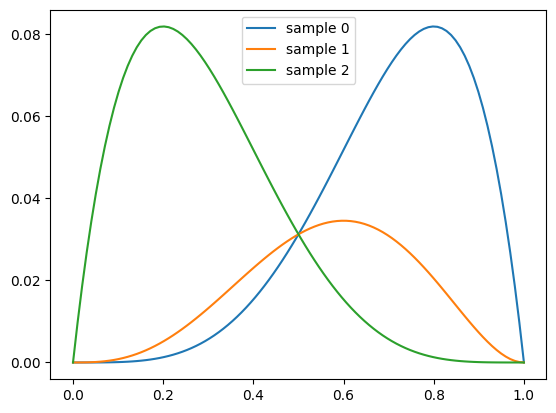

In [24]:
pplot = np.linspace(0, 1, num=100)
for i in range(3):
    X = np.random.binomial(1, p, N)  # Generate a new sample
    # evaluate the log-likelihood for each p in pplot separately to avoid broadcasting issues
    loglikes = np.array([log_likelihood(np.clip(pi, 1e-8, 1 - 1e-8), X) for pi in pplot])
    plt.plot(pplot, np.exp(loglikes), label=f'sample {i}')
plt.legend()
plt.show()

We can compute the maximum of the likelihood by taking the derivative of the log-likelihood and setting it equal to $0$. In the case of Bernoulli random variables we have a closed form solution and we don't need an optimization algorithm. However, in many real life application, the model is too complex and the likelihood equation cannot be solved in closed form. In this case, we can use an optimization algorithm.

# Maximum likelihood and optimization

The file "lifetimes.txt" (automatically downloaded in the first cell) contains some lifetime measures for $n=20$ industrial materials, the values are in thousands of hours. We import the dataset with panda library.

In [25]:
df = pd.read_csv('lifetimes.txt')
df.describe()

,times
count,20.000000
mean,0.885000
std,0.423364
min,0.100000
25%,0.600000
50%,0.800000
75%,1.300000
max,1.600000


### Question 3



In reliability studies, we often use the Weibull law whose density is given for some parameter $a>0$ by
$$\forall x>0, \quad f_a(x)=ax^{a-1}\exp(-x^a) $$
In scipy this distribution is called weibull_min

The negative log-likelihood is the log-likelihood multiplied by $-1$. It is the function we want to minimize to find the maximum likelihood estimator of $a$.

- Derive the negative log-likelihood of the Weibull model.
- Plot the negative log-likelihood for different values of $a$.

In [ ]:
from functools import partial


def weibull_neg_log_likelihood(a, x):
      # Compute the negative log-likelihood
      return -np.sum(stats.weibull_min.logpdf(x, a))


weibull_neg_log_likelihood = partial(weibull_neg_log_likelihood, x=df['times'])

aplot = np.linspace(0.1, 5)
plt.plot(aplot, ...)
plt.show()

### Question 4
Use an optimization algorithm to find the maximizer of the likelihood in a weibull model, call this estimator a_hat.

In [ ]:
from scipy.optimize import minimize

initial_guess = ...  # You have to make an initial guess to begin the iterative algorithm. Use Question 3.
res = minimize(weibull_neg_log_likelihood, initial_guess,
               options={'disp': True})  # do the minimization, display informations on the convergence.

*When using an optimization algorithm, if it does not converge straight-away, you may want to change the parameters of the algorithm. See scipy's documentation. The first thing to try is to change the method and the initial guess.*

In [ ]:
a_hat = res.x
print(f'The maximum likelihood estimator is {a_hat[0]}')

### Question 5

Plot the histogram of the data and the density estimated using the weibull model. Also make a QQ-plot to display the fit of the model (find out what it is). Is the model satisfying ?

In [ ]:
plt.hist(...)
xplot = np.linspace(..., ..., num=100) # Determine the range of the plot
density_weibull = lambda x: ...  # Define the density of the weibull model
plt.plot(xplot, density_weibull(xplot))

In [ ]:
sm.qqplot(...) # Make the QQ-plot
plt.show()

Is the Weibull a good fit for these data ?